In [110]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from astropy.table import Table, join, vstack
from astropy.io import fits, ascii
import pickle
from PyAstronomy import pyasl
from time import sleep
from tqdm.notebook import tqdm
import scipy
import warnings
import bottleneck as bn
warnings.filterwarnings("ignore")

In [111]:
# plotting parameters
plt.rc('axes', labelsize=12)
plt.rc('axes', labelweight='regular')
plt.rc('axes', titleweight='regular')
plt.rc('axes', linewidth=1)
plt.rc('xtick',labelsize=10,direction='in',top=True)
plt.rc('ytick',labelsize=10,direction='in',right=True)
plt.rcParams['xtick.major.pad']='10'
plt.rcParams['ytick.major.pad']='10'

paper_params = {
        'text.usetex' : True,
        'font.size'   : 10,
       #'font.family' : 'lmodern',
        'figure.dpi'  : 200
        }
plt.rcParams.update(paper_params)


In [350]:
def split_surf_file(surf_file):
    """
    from file string, extract
    model name,
    metallicity, 
    AGB mass
    inital mass
    final mass
    """
    model_name = surf_file.split('/')[-1][8:]
    metalZ = model_name.split('_')[-1][1:]
    AGB_mass = model_name.split('_')[-2][3:] #(model_name.split('_')[-2][3:4]+'.'+model_name.split('_')[-2][5:6])
    init_mass = (model_name.split('_')[0][1]+'.'+model_name.split('_')[0][3:5])
    final_mass = (model_name.split('_')[1][1]+'.'+model_name.split('_')[1][3:5])
    #if AGB_mass < init_mass: 
    #    return None
    return metalZ,AGB_mass,init_mass,final_mass

In [372]:
# or just get the WD masses directly from FRUITY, dont worry about some IM-FM relation. 
FRUITY_WDs = np.loadtxt('FRUITY_WD_masses.txt',skiprows=0,dtype=float).T

def get_WD_mass_from_FRUITY(m_agb,FeH):
    return FRUITY_WDs[np.where(np.isclose(FRUITY_WDs.T[0],FeH,rtol=7.5e-2,atol=7.5e-2))[0][0]][np.where(FRUITY_WDs[0] == m_agb)[0][0]]

In [413]:
# read histogram file with basic comparison output
hist_file = 'master_model_hist_list_full_metal_con_mass_free_weights.dat'
#hist_types = [str, float, float, float, float, float, float, str]
#hist_names = ['name','Z','mAGB','m_init','m_final','FeH','chi','flag']
hist_data = np.genfromtxt(hist_file,dtype=None,encoding='UTF-8')
hist_data = hist_data[::3]
len(hist_data)

267

In [420]:
def collect_data(data,flag):
    name = []
    z = []
    feh = []
    minit = []
    mfinal = []
    magb = []
    macc = []
    q = []
    mwd = []
    capQ = []
    acc_eff = []
    chi = []
    red_chi = []
    for i in range(len(data)):
        if data[i][-1] == flag:
            if data[i][-3] < 51 and data[i][-2] < 4.1 and data[i][4] < 5.1:
                name.append(data[i][0])
                z.append(np.log10(data[i][1]/0.0142))
                feh.append(data[i][5])
                minit.append(data[i][3])
                mfinal.append(data[i][4])
                magb.append(data[i][2])
                macc.append(data[i][4] - data[i][3])
                q.append(data[i][3] / data[i][2])
                m_wd = get_WD_mass_from_FRUITY(data[i][2],np.log10(data[i][1]/0.0142))
                mwd.append(m_wd)
                capQ.append(m_wd**3 / (data[i][4] + m_wd)**2)
                acc_eff.append((data[i][4] - data[i][3]) / (data[i][2] - m_wd) * 100)
                chi.append(data[i][-3])
                red_chi.append(data[i][-2])
            else: 
                continue
    return name,z,feh,minit,mfinal,magb,macc,q,mwd,capQ,acc_eff,chi,red_chi
## read the data, categorize
cemps_names,cemps_z,cemps_feh,cemps_minit,cemps_mfinal,cemps_magb,cemps_macc,cemps_q,cemps_mwd,cemps_capQ,cemps_acc_eff,cemps_chis,cemps_red_chis = collect_data(hist_data,'CEMP-s')
cempr_names,cempr_z,cempr_feh,cempr_minit,cempr_mfinal,cempr_magb,cempr_macc,cempr_q,cempr_mwd,cempr_capQ,cempr_acc_eff,cempr_chis,cempr_red_chis = collect_data(hist_data,'CEMP-r')
cemprs_names,cemprs_z,cemprs_feh,cemprs_minit,cemprs_mfinal,cemprs_magb,cemprs_macc,cemprs_q,cemprs_mwd,cemprs_capQ,cemprs_acc_eff,cemprs_chis,cemprs_red_chis = collect_data(hist_data,'CEMP-r/s')
cempno_names,cempno_z,cempno_feh,cempno_minit,cempno_mfinal,cempno_magb,cempno_macc,cempno_q,cempno_mwd,cempno_capQ,cempno_acc_eff,cempno_chis,cempno_red_chis = collect_data(hist_data,'CEMP-no')
wba_names,wba_z,wba_feh,wba_minit,wba_mfinal,wba_magb,wba_macc,wba_q,wba_mwd,wba_capQ,wba_acc_eff,wba_chis,wba_red_chis = collect_data(hist_data,'WBa')
sba_names,sba_z,sba_feh,sba_minit,sba_mfinal,sba_magb,sba_macc,sba_q,sba_mwd,sba_capQ,sba_acc_eff,sba_chis,sba_red_chis = collect_data(hist_data,'SBa')
ch_names,ch_z,ch_feh,ch_minit,ch_mfinal,ch_magb,ch_macc,ch_q,ch_mwd,ch_capQ,ch_acc_eff,ch_chis,ch_red_chis = collect_data(hist_data,'CH')
empty_names,empty_z,empty_feh,empty_minit,empty_mfinal,empty_magb,empty_macc,empty_q,empty_mwd,empty_capQ,empty_acc_eff,empty_chis,empty_red_chis = collect_data(hist_data,'empty')
## concat all into some arrays
full_names = np.concatenate([cemps_names,cemprs_names,cempr_names,cempno_names,wba_names,sba_names,ch_names,empty_names])
full_z = np.concatenate([cemps_z,cemprs_z,cempr_z,cempno_z,wba_z,sba_z,ch_z,empty_z])
full_feh = np.concatenate([cemps_feh,cemprs_feh,cempr_feh,cempno_feh,wba_feh,sba_feh,ch_feh,empty_feh])
full_minit = np.concatenate([cemps_minit,cemprs_minit,cempr_minit,cempno_minit,wba_minit,sba_minit,ch_minit,empty_minit])
full_mfinal = np.concatenate([cemps_mfinal,cemprs_mfinal,cempr_mfinal,cempno_mfinal,wba_mfinal,sba_mfinal,ch_mfinal,empty_mfinal])
full_magb = np.concatenate([cemps_magb,cemprs_magb,cempr_magb,cempno_magb,wba_magb,sba_magb,ch_magb,empty_magb])
full_macc = np.concatenate([cemps_macc,cemprs_macc,cempr_macc,cempno_macc,wba_macc,sba_macc,ch_macc,empty_macc])
full_q = np.concatenate([cemps_q,cemprs_q,cempr_q,cempno_q,wba_q,sba_q,ch_q,empty_q])
full_mwd = np.concatenate([cemps_mwd,cemprs_mwd,cempr_mwd,cempno_mwd,wba_mwd,sba_mwd,ch_mwd,empty_mwd])
full_capQ = np.concatenate([cemps_capQ,cemprs_capQ,cempr_capQ,cempno_capQ,wba_capQ,sba_capQ,ch_capQ,empty_capQ])
full_acc_eff = np.concatenate([cemps_acc_eff,cemprs_acc_eff,cempr_acc_eff,cempno_acc_eff,wba_acc_eff,sba_acc_eff,ch_acc_eff,empty_acc_eff])
full_chis = np.concatenate([cemps_chis,cemprs_chis,cempr_chis,cempno_chis,wba_chis,sba_chis,ch_chis,empty_chis])
full_red_chis = np.concatenate([cemps_red_chis,cemprs_red_chis,cempr_red_chis,cempno_red_chis,wba_red_chis,sba_red_chis,ch_red_chis,empty_red_chis])

print('# of stars by category:')
print('CEMP-s',len(cemps_feh));print('CEMP-r/s',len(cemprs_feh));print('CEMP-r',len(cempr_feh));print('CEMP-no',len(cempno_feh));print('CH',len(ch_feh));
print('weak Ba',len(wba_feh));print('strong Ba',len(sba_feh));print('None',len(empty_feh))

# of stars by category:
CEMP-s 21
CEMP-r/s 8
CEMP-r 0
CEMP-no 0
CH 22
weak Ba 83
strong Ba 90
None 3


Text(0, 0.5, '$\\rm{Observed\\;[Fe/H]}$')

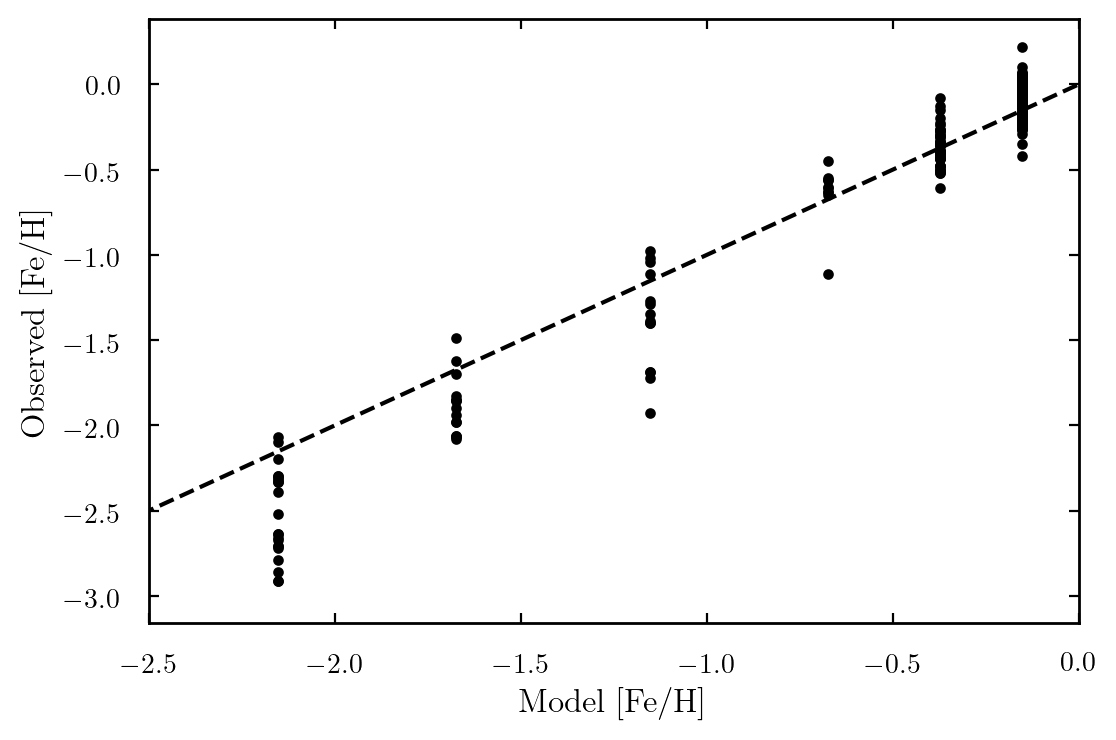

In [421]:
x = np.linspace(-3,0,100)
fig,ax = plt.subplots()
ax.scatter(full_z,full_feh,s=8,c='black')
ax.plot(x,x,ls='--',c='black')
ax.set_xlim(-2.50,0.0)
ax.set_xlabel(r'$\rm{Model\;[Fe/H]}$')
ax.set_ylabel(r'$\rm{Observed\;[Fe/H]}$')

M_initial
1.136111111111111 0.6451110058560025
1.5789156626506025 0.8653337152049168
1.7261904761904763 1.143992491610709
0.9818181818181819 0.5739705120999951
m_final
1.8599999999999997 0.6935095929801949
2.121686746987952 0.8279817518463934
2.2904761904761903 1.3453286947999565
1.4340909090909093 0.6833051966255907
M_acc
0.7238888888888889 0.31324713156244344
0.5427710843373493 0.3204977802040003
0.5642857142857144 0.4259842544437688
0.4522727272727274 0.428389497984569


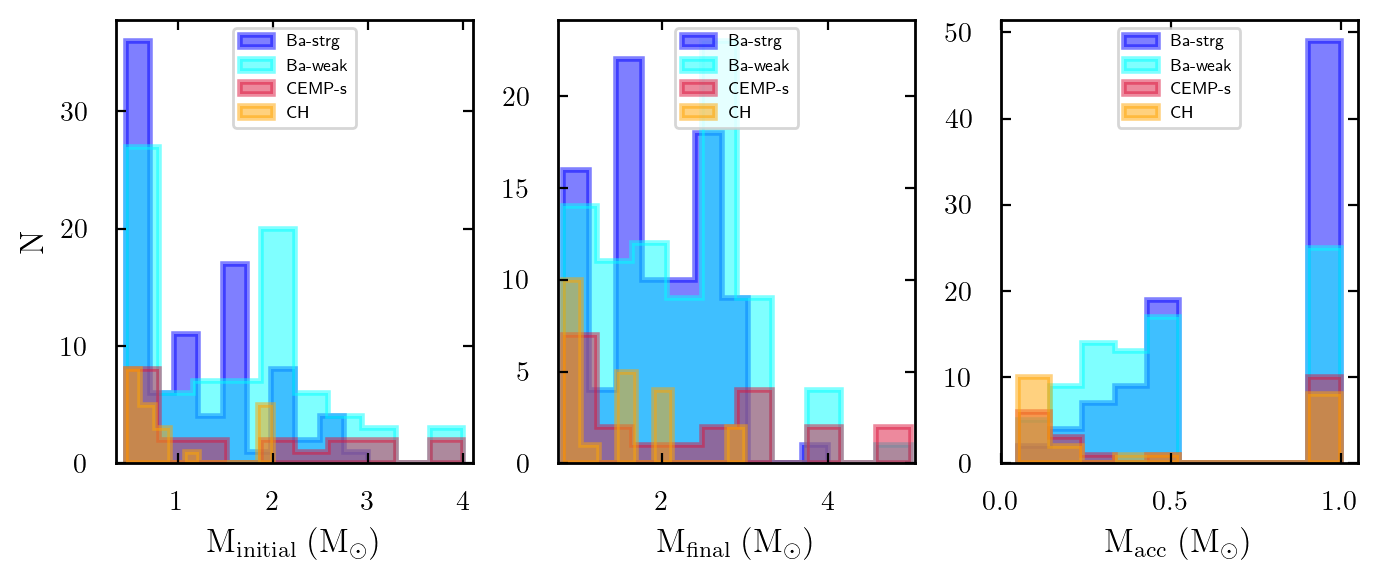

In [422]:
fig, ((ax1,ax2,ax3)) = plt.subplots(ncols=3,nrows=1,figsize=(7,3),dpi=200,sharey=False)
ax1.set_ylabel(r'$\rm{N}$')
ax1.set_xlabel(r'$\rm{M_{initial}\; (M_{\odot})}$')
ax2.set_xlabel(r'$\rm{M_{final}\; (M_{\odot})}$')
ax3.set_xlabel(r'$\rm{M_{acc}\; (M_{\odot})}$')
#ax3.set_ylabel(r'$\rm{N}$')
#ax3.set_xlabel(r'$\rm{M_{AGB}\; (M_{\odot})}$')
#ax4.set_xlabel(r'$\rm{q}$')#ax4.set_xlabel(r'$\rm{M_{acc}\; (M_{\odot})}$')
# ----------------------------------------------------------------------------------------------------------------------------------
print('M_initial')
_, bins, _  = ax1.hist(sba_minit, density=False, histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='blue', color='blue', label='Ba-strg');      
mu, sigma = scipy.stats.norm.fit(sba_minit)
print(mu,sigma)
best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
#ax1.plot(bins, best_fit_line,color='blue')

_, bins, _ = ax1.hist(wba_minit, density=False, histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='cyan', color='cyan', label='Ba-weak');      
mu, sigma = scipy.stats.norm.fit(wba_minit)
print(mu,sigma)
best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
#ax1.plot(bins, best_fit_line,color='cyan')

#_, bins, _ = ax1.hist(cemprs_minit, density=True, histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='black', color='black', label='CEMP-rs');    
#mu, sigma = scipy.stats.norm.fit(cemprs_minit)
#print(mu,sigma)
#best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
#ax1.plot(bins, best_fit_line,color='black')

_, bins, _ = ax1.hist(cemps_minit, density=False, histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='crimson', color='crimson', label='CEMP-s');    
mu, sigma = scipy.stats.norm.fit(cemps_minit)
print(mu,sigma)
best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
#ax1.plot(bins, best_fit_line,color='crimson')

_, bins, _ = ax1.hist(ch_minit, density=False, histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='orange', color='orange', label='CH');      
mu, sigma = scipy.stats.norm.fit(ch_minit)
print(mu,sigma)
best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
#ax1.plot(bins, best_fit_line,color='orange')

#ax1.hist(empty_feh,   histtype='stepfilled', alpha=0.33, linewidth=2.0, edgecolor='black'     , color='black'     , label='None');       

ax1.legend(loc='upper center',fontsize=6)
ax1.set_xlim(np.array(full_minit).min()-0.1,np.array(full_minit).max()+0.1)
# ----------------------------------------------------------------------------------------------------------------------------------
print('m_final')
#ax2.hist(cemps_minit, histtype='step', alpha=0.50, linewidth=2.0, edgecolor='crimson'   , color='crimson'   , label='CEMP-s')
#ax2.hist(ch_minit,    histtype='step', alpha=0.50, linewidth=2.0, edgecolor='darkorange', color='darkorange', label='CH')
#ax2.hist(sba_minit,   histtype='step', alpha=0.50, linewidth=2.0, edgecolor='blue'      , color='blue'      , label='Ba-strg')
#ax2.hist(wba_minit,   histtype='step', alpha=0.50, linewidth=2.0, edgecolor='cyan'      , color='cyan'      , label='Ba-weak')

_, bins, _ = ax2.hist(sba_mfinal,  density=False, histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='blue', color='blue', label='Ba-strg')
mu, sigma = scipy.stats.norm.fit(sba_mfinal)
print(mu,sigma)
best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
#ax2.plot(bins, best_fit_line,color='blue')

_, bins, _ = ax2.hist(wba_mfinal,  density=False, histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='cyan', color='cyan', label='Ba-weak')
mu, sigma = scipy.stats.norm.fit(wba_mfinal)
print(mu,sigma)
best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
#ax2.plot(bins, best_fit_line,color='cyan')

#_, bins, _ = ax2.hist(cemprs_mfinal,density=True, histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='black', color='black', label='CEMP-rs')
#mu, sigma = scipy.stats.norm.fit(cemprs_mfinal)
#print(mu,sigma)
#best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
#ax2.plot(bins, best_fit_line,color='black')

_, bins, _ = ax2.hist(cemps_mfinal,density=False, histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='crimson', color='crimson', label='CEMP-s')
mu, sigma = scipy.stats.norm.fit(cemps_mfinal)
print(mu,sigma)
best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
#ax2.plot(bins, best_fit_line,color='crimson')

_, bins, _ = ax2.hist(ch_mfinal,   density=False, histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='orange', color='orange', label='CH')
mu, sigma = scipy.stats.norm.fit(ch_mfinal)
print(mu,sigma)
best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
#ax2.plot(bins, best_fit_line,color='orange')

#ax2.hist(empty_mfinal,histtype='stepfilled', alpha=0.33, linewidth=2.0, edgecolor='black'     , color='black'     , label='None')

ax2.legend(loc='upper center',fontsize=6)
ax2.set_xlim(np.array(full_mfinal).min()-0.05,np.array(full_mfinal).max()+0.05)
# ----------------------------------------------------------------------------------------------------------------------------------
print('M_acc')
_, bins, _ = ax3.hist(sba_macc,    density=False, histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='blue', color='blue', label='Ba-strg')
mu, sigma = scipy.stats.norm.fit(sba_macc)
print(mu,sigma)
best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
#ax3.plot(bins, best_fit_line,color='blue')

_, bins, _ = ax3.hist(wba_macc,    density=False, histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='cyan', color='cyan', label='Ba-weak')
mu, sigma = scipy.stats.norm.fit(wba_macc)
print(mu,sigma)
best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
#ax3.plot(bins, best_fit_line,color='cyan')

#_, bins, _ = ax3.hist(cemprs_macc,  density=True, histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='black', color='black', label='CEMP-rs')
#mu, sigma = scipy.stats.norm.fit(cemprs_macc)
#print(mu,sigma)
#best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
#ax3.plot(bins, best_fit_line,color='black')

_, bins, _ = ax3.hist(cemps_macc,  density=False, histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='crimson', color='crimson', label='CEMP-s')
mu, sigma = scipy.stats.norm.fit(cemps_macc)
print(mu,sigma)
best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
#ax3.plot(bins, best_fit_line,color='crimson')

_, bins, _ = ax3.hist(ch_macc,     density=False, histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='orange', color='orange', label='CH')
mu, sigma = scipy.stats.norm.fit(ch_macc)
print(mu,sigma)
best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
#ax3.plot(bins, best_fit_line,color='orange')

#ax3.hist(empty_magb,  histtype='stepfilled', alpha=0.33, linewidth=2.0, edgecolor='black'     , color='black'     , label='None')

ax3.legend(loc='upper center',fontsize=6)
ax3.set_xlim(np.array(full_macc).min()-0.05,np.array(full_macc).max()+0.05)
# ----------------------------------------------------------------------------------------------------------------------------------
#print('q')
#_, bins, _ = ax4.hist(sba_q, density=True, histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='blue', color='blue', label='Ba-strg')
#mu, sigma = scipy.stats.norm.fit(sba_q)
#print(mu,sigma)
#best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
#ax4.plot(bins, best_fit_line,color='blue')
#
#_, bins, _ = ax4.hist(wba_q, density=True, histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='cyan', color='cyan', label='Ba-weak')
#mu, sigma = scipy.stats.norm.fit(wba_q)
#print(mu,sigma)
#best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
#ax4.plot(bins, best_fit_line,color='cyan')
#
#_, bins, _ = ax4.hist(cemprs_q, density=True, histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='black', color='black', label='CEMP-rs')
#mu, sigma = scipy.stats.norm.fit(cemps_q)
#print(mu,sigma)
#best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
#ax4.plot(bins, best_fit_line,color='black')
#
#_, bins, _ = ax4.hist(cemps_q, density=True, histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='crimson', color='crimson', label='CEMP-s')
#mu, sigma = scipy.stats.norm.fit(cemps_q)
#print(mu,sigma)
#best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
#ax4.plot(bins, best_fit_line,color='crimson')
#
#_, bins, _ = ax4.hist(ch_q, density=True, histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='orange', color='orange', label='CH')
#mu, sigma = scipy.stats.norm.fit(ch_q)
#print(mu,sigma)
#best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
#ax4.plot(bins, best_fit_line,color='orange')
#
##ax4.hist(empty_macc,  histtype='stepfilled', alpha=0.33, linewidth=2.0, edgecolor='black'     , color='black'     , label='None')
#
#ax4.legend(loc=0,fontsize=6)
#ax4.set_xlim(np.array(full_q).min()-0.1,np.array(full_q).max()+0.1)

plt.tight_layout()
#plt.savefig('hist_full_mass_con_metal_con_gaussians.png',dpi=200,bbox_inches='tight')

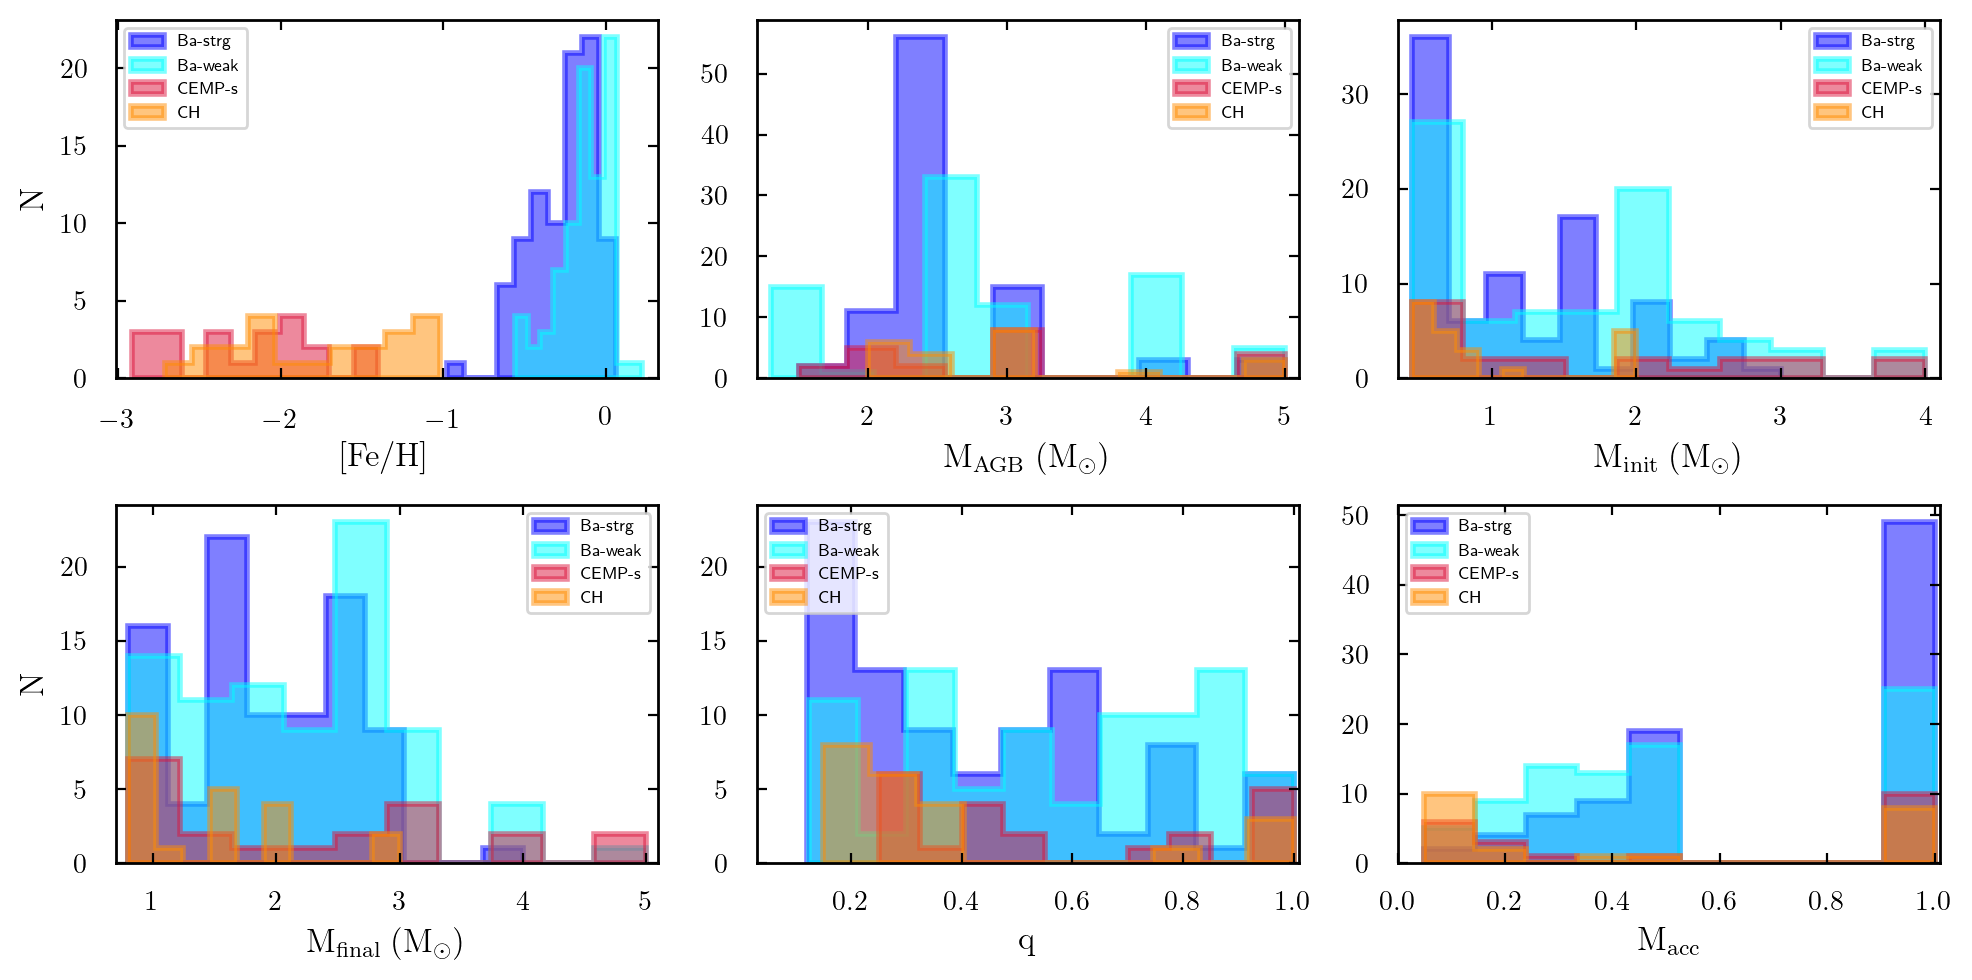

In [424]:
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6)) = plt.subplots(ncols=3,nrows=2,figsize=(10,5),dpi=200,sharey=False)
ax1.set_ylabel(r'$\rm{N}$')
ax1.set_xlabel(r'$\rm{[Fe/H]}$')

#ax2.set_ylabel(r'$\rm{N}$')
ax2.set_xlabel(r'$\rm{M_{AGB}\; (M_{\odot})}$')

#ax3.set_ylabel(r'$\rm{N}$')
ax3.set_xlabel(r'$\rm{M_{init}\; (M_{\odot})}$')

ax4.set_ylabel(r'$\rm{N}$')
ax4.set_xlabel(r'$\rm{M_{final}\; (M_{\odot})}$')

#ax5.set_ylabel(r'$\rm{N}$')
ax5.set_xlabel(r'$\rm{q}$')

#ax6.set_ylabel(r'$\rm{N}$')
ax6.set_xlabel(r'$\rm{M_{acc}}$')

ax1.hist(sba_feh,     histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='blue'      , color='blue'      , label='Ba-strg');      
ax1.hist(wba_feh,     histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='cyan'      , color='cyan'      , label='Ba-weak');      
#ax1.hist(cemprs_feh,   histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='black'   , color='black'   , label='CEMP-rs');    
ax1.hist(cemps_feh,   histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='crimson'   , color='crimson'   , label='CEMP-s');    
ax1.hist(ch_feh,      histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='darkorange', color='darkorange', label='CH');      
#ax1.hist(empty_feh,   histtype='stepfilled', alpha=0.33, linewidth=2.0, edgecolor='black'     , color='black'     , label='None');       

ax1.legend(loc=0,fontsize=6)
ax1.set_xlim(np.array(full_feh).min()-0.1,np.array(full_feh).max()+0.1)

ax2.hist(sba_magb,    histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='blue'      , color='blue'      , label='Ba-strg')
ax2.hist(wba_magb,    histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='cyan'      , color='cyan'      , label='Ba-weak')
#ax2.hist(cemprs_magb,  histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='black'   , color='black'   , label='CEMP-rs')
ax2.hist(cemps_magb,  histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='crimson'   , color='crimson'   , label='CEMP-s')
ax2.hist(ch_magb,     histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='darkorange', color='darkorange', label='CH')
#ax2.hist(empty_magb,  histtype='stepfilled', alpha=0.33, linewidth=2.0, edgecolor='black'     , color='black'     , label='None')

ax2.legend(loc=0,fontsize=6)
ax2.set_xlim(np.array(full_magb).min()-0.1,np.array(full_magb).max()+0.1)

ax3.hist(sba_minit,  histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='blue'      , color='blue'      , label='Ba-strg')
ax3.hist(wba_minit,  histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='cyan'      , color='cyan'      , label='Ba-weak')
#ax3.hist(cemprs_minit,histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='black'   , color='black'   , label='CEMP-rs')
ax3.hist(cemps_minit,histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='crimson'   , color='crimson'   , label='CEMP-s')
ax3.hist(ch_minit,   histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='darkorange', color='darkorange', label='CH')
#ax3.hist(empty_minit,histtype='stepfilled', alpha=0.33, linewidth=2.0, edgecolor='black'     , color='black'     , label='None')

ax3.legend(loc=0,fontsize=6)
ax3.set_xlim(np.array(full_minit).min()-0.1,np.array(full_minit).max()+0.1)

ax4.hist(sba_mfinal,  histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='blue'      , color='blue'      , label='Ba-strg')
ax4.hist(wba_mfinal,  histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='cyan'      , color='cyan'      , label='Ba-weak')
#ax4.hist(cemprs_mfinal,histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='black'   , color='black'   , label='CEMP-rs')
ax4.hist(cemps_mfinal,histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='crimson'   , color='crimson'   , label='CEMP-s')
ax4.hist(ch_mfinal,   histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='darkorange', color='darkorange', label='CH')
#ax4.hist(empty_mfinal,histtype='stepfilled', alpha=0.33, linewidth=2.0, edgecolor='black'     , color='black'     , label='None')

ax4.legend(loc=0,fontsize=6)
ax4.set_xlim(np.array(full_mfinal).min()-0.1,np.array(full_mfinal).max()+0.1)

ax5.hist(sba_q,    histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='blue'      , color='blue'      , label='Ba-strg')
ax5.hist(wba_q,    histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='cyan'      , color='cyan'      , label='Ba-weak')
#ax5.hist(cemprs_q,  histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='black'   , color='black'   , label='CEMP-rs')
ax5.hist(cemps_q,  histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='crimson'   , color='crimson'   , label='CEMP-s')
ax5.hist(ch_q,     histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='darkorange', color='darkorange', label='CH')
#ax54.hist(empty_macc,  histtype='stepfilled', alpha=0.33, linewidth=2.0, edgecolor='black'     , color='black'     , label='None')

ax5.legend(loc='upper left',fontsize=6)
ax5.set_xlim(np.array(full_q).min()-0.09,np.array(full_q).max()+0.01)

ax6.hist(sba_macc,    histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='blue'      , color='blue'      , label='Ba-strg')
ax6.hist(wba_macc,    histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='cyan'      , color='cyan'      , label='Ba-weak')
#ax6.hist(cemprs_macc,  histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='black'   , color='black'   , label='CEMP-rs')
ax6.hist(cemps_macc,  histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='crimson'   , color='crimson'   , label='CEMP-s')
ax6.hist(ch_macc,     histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='darkorange', color='darkorange', label='CH')

ax6.legend(loc='upper left',fontsize=6)
ax6.set_xlim(np.array(full_macc).min()-0.05,np.array(full_macc).max()+0.01)
#ax2.set_ylim(0,15)
plt.tight_layout()
#plt.savefig('hist_full_metal_free_mass_con2.png',dpi=200,bbox_inches='tight')

single gaussian 0.5470930232558139 0.3187324688441877

double gaussian parameters
mu1  0.3863897903225189 0.05979667415067937
sig1 0.1401556323547381 0.060451114352659374
A1   8.313939579281321 3.0748908547523803
mu2  0.9950158866267804 175491.53361585946
sig2 0.013595084488049603 28357.7807294575
A2   67.40025049158672 912125842.7286463

overfit? this value should be small 3.13810309659353e+22


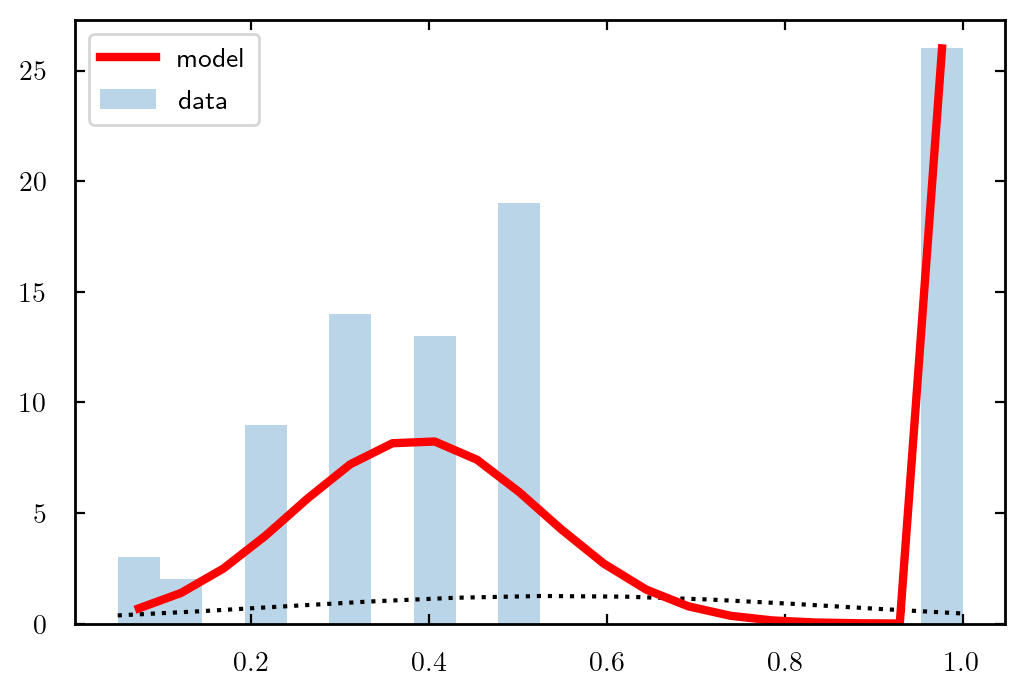

In [402]:
# check bimodality in (mass) distributions
from pylab import *
from scipy.optimize import curve_fit

gauss_data = wba_macc

# try just a single gaussian...
mu, sigma = scipy.stats.norm.fit(gauss_data)
print('single gaussian',mu,sigma)
best_fit_line = scipy.stats.norm.pdf(bins, mu, sigma)
plt.plot(bins, best_fit_line,color='black',ls=':')

print()
y,x,_=hist(gauss_data,bins=20,alpha=.3,label='data')
x=(x[1:]+x[:-1])/2 # for len(x)==len(y)

def gauss(x,mu,sigma,A):
    return A*exp(-(x-mu)**2/2/sigma**2)

def bimodal(x,mu1,sigma1,A1,mu2,sigma2,A2):
    return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)

# mu, sigma, height , mu, sigma, height
expected=(0.1,0.10,10, 1.0,0.10,10)

params,cov=curve_fit(bimodal,x,y,expected)
sigma=sqrt(diag(cov))

plt.plot(x,bimodal(x,*params),color='red',lw=3,label='model')
plt.legend()
print('double gaussian parameters')
print('mu1 ',params[0],sigma[0])
print('sig1',params[1],sigma[1])
print('A1  ',params[2],sigma[2])
print('mu2 ',params[3],sigma[3])
print('sig2',params[4],sigma[4])
print('A2  ',params[5],sigma[5])

print('\noverfit? this value should be small',np.linalg.cond(cov))

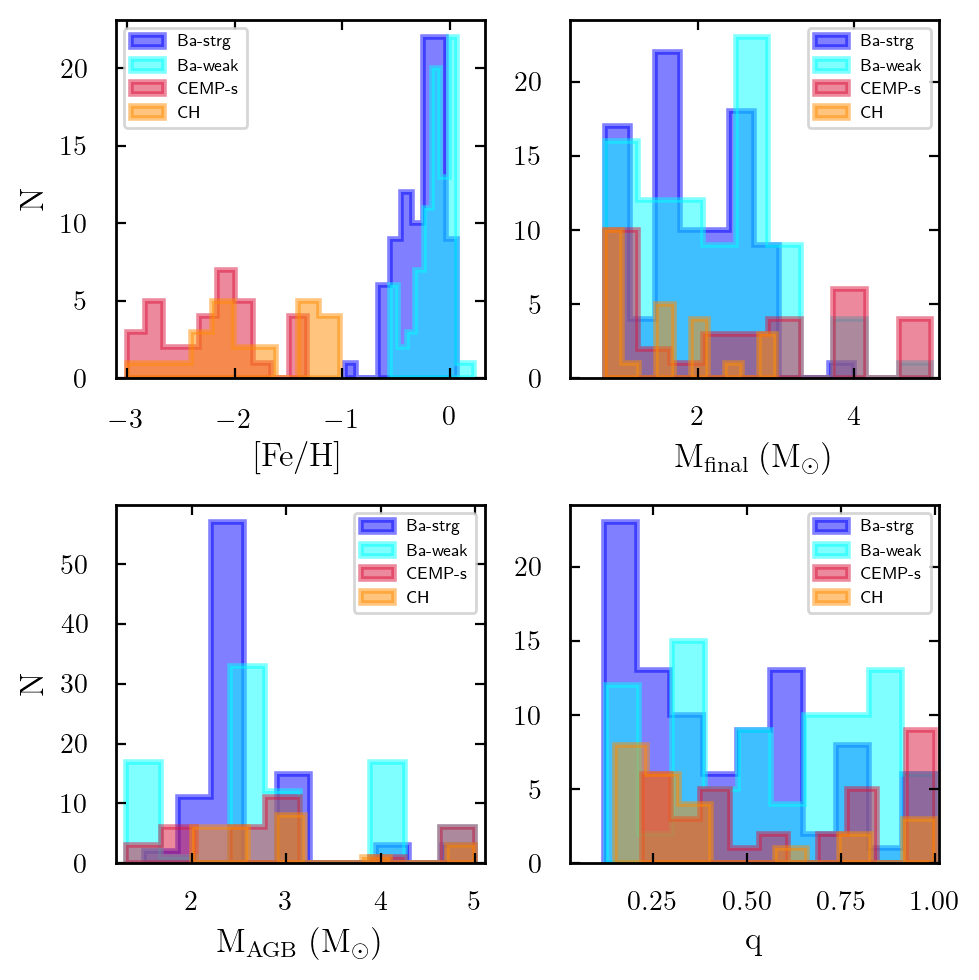

In [403]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(ncols=2,nrows=2,figsize=(5,5),dpi=200,sharey=False)
ax1.set_ylabel(r'$\rm{N}$')
ax1.set_xlabel(r'$\rm{[Fe/H]}$')
ax2.set_xlabel(r'$\rm{M_{final}\; (M_{\odot})}$')

ax3.set_ylabel(r'$\rm{N}$')
ax3.set_xlabel(r'$\rm{M_{AGB}\; (M_{\odot})}$')
ax4.set_xlabel(r'$\rm{q}$')

ax1.hist(sba_feh,     histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='blue'      , color='blue'      , label='Ba-strg');      
ax1.hist(wba_feh,     histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='cyan'      , color='cyan'      , label='Ba-weak');      
ax1.hist(cemps_feh,   histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='crimson'   , color='crimson'   , label='CEMP-s');    
ax1.hist(ch_feh,      histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='darkorange', color='darkorange', label='CH');      
#ax1.hist(empty_feh,   histtype='stepfilled', alpha=0.33, linewidth=2.0, edgecolor='black'     , color='black'     , label='None');       

ax1.legend(loc=0,fontsize=6)
ax1.set_xlim(np.array(full_feh).min()-0.1,np.array(full_feh).max()+0.1)

#ax2.hist(cemps_minit,histtype='step', alpha=0.50, linewidth=2.0, edgecolor='crimson'   , color='crimson'   , label='CEMP-s')
#ax2.hist(ch_minit,   histtype='step', alpha=0.50, linewidth=2.0, edgecolor='darkorange', color='darkorange', label='CH')
#ax2.hist(sba_minit,  histtype='step', alpha=0.50, linewidth=2.0, edgecolor='blue'      , color='blue'      , label='Ba-strg')
#ax2.hist(wba_minit,  histtype='step', alpha=0.50, linewidth=2.0, edgecolor='cyan'      , color='cyan'      , label='Ba-weak')

ax2.hist(sba_mfinal,  histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='blue'      , color='blue'      , label='Ba-strg')
ax2.hist(wba_mfinal,  histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='cyan'      , color='cyan'      , label='Ba-weak')
ax2.hist(cemps_mfinal,histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='crimson'   , color='crimson'   , label='CEMP-s')
ax2.hist(ch_mfinal,   histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='darkorange', color='darkorange', label='CH')
#ax2.hist(empty_mfinal,histtype='stepfilled', alpha=0.33, linewidth=2.0, edgecolor='black'     , color='black'     , label='None')

ax2.legend(loc=0,fontsize=6)
ax2.set_xlim(np.array(full_minit).min()-0.1,np.array(full_mfinal).max()+0.1)

ax3.hist(sba_magb,    histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='blue'      , color='blue'      , label='Ba-strg')
ax3.hist(wba_magb,    histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='cyan'      , color='cyan'      , label='Ba-weak')
ax3.hist(cemps_magb,  histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='crimson'   , color='crimson'   , label='CEMP-s')
ax3.hist(ch_magb,     histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='darkorange', color='darkorange', label='CH')
#ax3.hist(empty_magb,  histtype='stepfilled', alpha=0.33, linewidth=2.0, edgecolor='black'     , color='black'     , label='None')

ax3.legend(loc=0,fontsize=6)
ax3.set_xlim(np.array(full_magb).min()-0.1,np.array(full_magb).max()+0.1)

ax4.hist(sba_q,    histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='blue'      , color='blue'      , label='Ba-strg')
ax4.hist(wba_q,    histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='cyan'      , color='cyan'      , label='Ba-weak')
ax4.hist(cemps_q,  histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='crimson'   , color='crimson'   , label='CEMP-s')
ax4.hist(ch_q,     histtype='stepfilled', alpha=0.50, linewidth=2.0, edgecolor='darkorange', color='darkorange', label='CH')
#ax4.hist(empty_macc,  histtype='stepfilled', alpha=0.33, linewidth=2.0, edgecolor='black'     , color='black'     , label='None')

ax4.legend(loc=0,fontsize=6)
ax4.set_xlim(np.array(full_q).min()-0.09,np.array(full_q).max()+0.01)

plt.tight_layout()
#plt.savefig('hist_full_metal_con_mass_con.png',dpi=200,bbox_inches='tight')

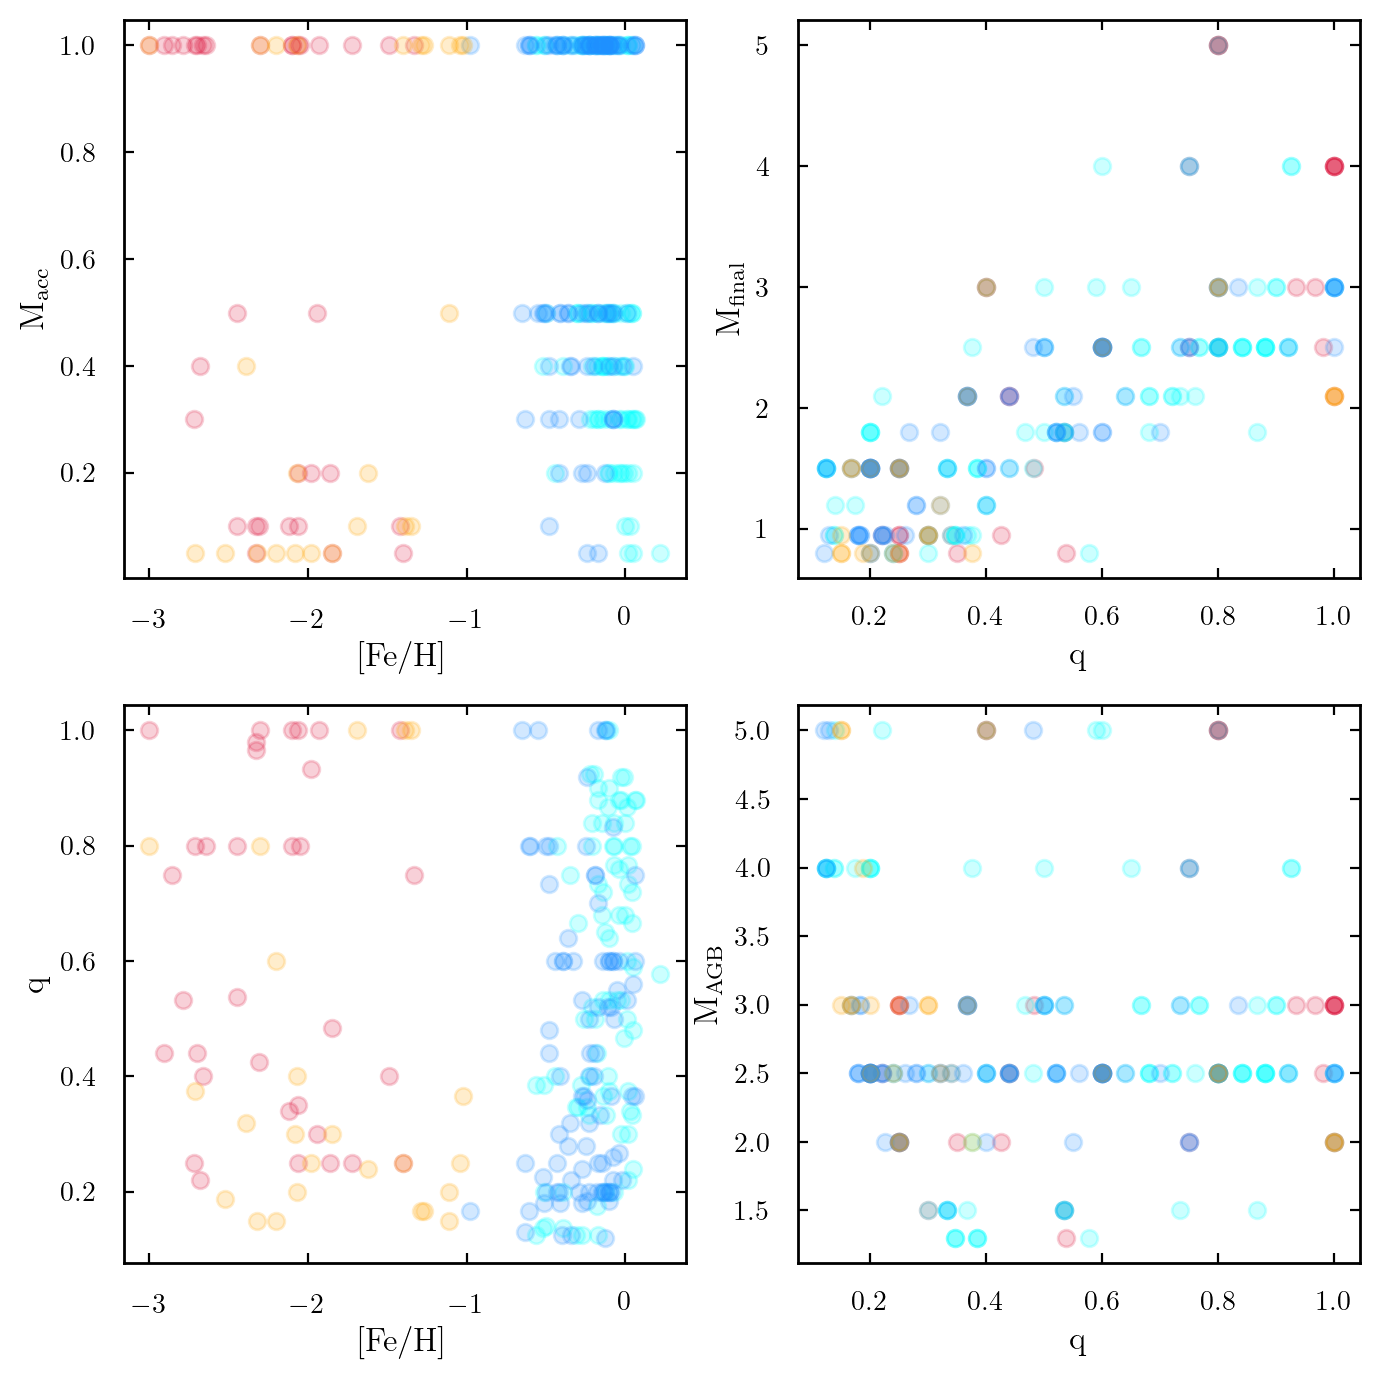

In [404]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(ncols=2,nrows=2,figsize=(7,7),dpi=200)

ax1.set_ylabel(r'$\rm{M_{acc}}$'); ax1.set_xlabel(r'$\rm[Fe/H]$')
ax2.set_ylabel(r'$\rm{M_{final}}$'); ax2.set_xlabel(r'$\rm{q}$')
ax3.set_ylabel(r'$\rm{q}$');       ax3.set_xlabel(r'$\rm{[Fe/H]}$')
ax4.set_ylabel(r'$\rm{M_{AGB}}$'); ax4.set_xlabel(r'$\rm{q}$')

ax1.scatter(cemps_feh,cemps_macc,alpha=0.20,c='crimson')
ax1.scatter(wba_feh,wba_macc,alpha=0.20,c='cyan')
ax1.scatter(sba_feh,sba_macc,alpha=0.20,c='dodgerblue')
ax1.scatter(ch_feh,ch_macc,alpha=0.20,c='orange')

ax2.scatter(cemps_q,cemps_mfinal,alpha=0.20,c='crimson')
ax2.scatter(wba_q,wba_mfinal,alpha=0.20,c='cyan')
ax2.scatter(sba_q,sba_mfinal,alpha=0.20,c='dodgerblue')
ax2.scatter(ch_q,ch_mfinal,alpha=0.20,c='orange')

ax3.scatter(cemps_feh,cemps_q,alpha=0.20,c='crimson')
ax3.scatter(wba_feh,wba_q,alpha=0.20,c='cyan')
ax3.scatter(sba_feh,sba_q,alpha=0.20,c='dodgerblue')
ax3.scatter(ch_feh,ch_q,alpha=0.20,c='orange')

ax4.scatter(cemps_q,cemps_magb,alpha=0.20,c='crimson')
ax4.scatter(wba_q,wba_magb,alpha=0.20,c='cyan')
ax4.scatter(sba_q,sba_magb,alpha=0.20,c='dodgerblue')
ax4.scatter(ch_q,ch_magb,alpha=0.20,c='orange')

plt.tight_layout()
#plt.savefig('scatter_full_metal_free_mass_con.png',dpi=200,bbox_inches=None)